In [111]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [112]:
!pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl triton cut_cross_entropy unsloth_zoo
!pip install sentencepiece protobuf 
!pip install --no-deps unsloth
%pip install -U wandb
!pip install --upgrade torchao==0.16.0

Note: you may need to restart the kernel to use updated packages.


In [113]:
import os
from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = secrets.get_secret("WANDB_API_KEY")
os.environ["WANDB_PROJECT"] = "deepseek-r1-LoRA-smol"
print(bool(os.environ.get("WANDB_API_KEY")))  # True

True


In [114]:
from huggingface_hub import login
secrets = UserSecretsClient()
os.environ["Hugging Face"] = secrets.get_secret("Hugging Face")
login(token=os.environ["Hugging Face"])
print(bool(os.environ.get("Hugging Face")))

True


In [115]:
from unsloth import FastVisionModel
###Actually a performance wrapper,unsloth pulls the model from hf but it's wraps it around the unsloth framework
import torch

In [116]:
model,tokenizer=FastVisionModel.from_pretrained("unsloth/Qwen2-VL-7B-Instruct",load_in_4bit=True,use_gradient_checkpointing="unsloth")

==((====))==  Unsloth 2026.9.4: Fast Qwen2_Vl patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 6.283 GiB
no_split classes   : ['Qwen2VLDecoderLayer', 'Qwen2VLVisionBlock']
output head        : lm_head -> cuda:1
head headroom      : 0.359 GiB
activation reserve : 0.781 GiB requested
  cuda:0  budget   3.98 GiB  weights  3.146 GiB  free  0.835 GiB  reserve  0.781 GiB
  cuda:1  budget   4.22 GiB  weights  3.137 GiB  free  1.086 GiB  reserve  0.723 GiB   <- output head
note: Bnb4BitHfQuantizer.adjust_max_memory lowered the budget on cuda:0 4.423 -> 3.980 GiB, cuda:1 4.692 -> 4.223 GiB (memory the quantiser keeps for its

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

In [117]:
model=FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,
    lora_alpha=32,
    lora_dropout=0,
    bias="none",
    use_rslora=False,
    loftq_config=None
)

In [118]:
from datasets import load_dataset,Dataset
raw_dataset=load_dataset("unsloth/Latex_OCR",split="train")

In [119]:
raw_dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

In [140]:
raw_dataset[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>,
 'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}

In [121]:
def convert_to_chatml(sample):
    conversation=[
                {                                ####begins
                    "role":"user","content":[
                        {"type":"text","text":"Write the Latex representation for this image"},               ####User part
                        {"type":"image","image":sample['image']}
                    ]
                },                              ####ends
                {
                    "role":"assistant","content":[                     ####begins
                        {"type":"text","text":sample['text']}                            ###Assistant Part
                    ]
                }                                                     ####ends
            ]
    return {"messages":conversation}

In [122]:
dataset=[convert_to_chatml(row) for row in raw_dataset]
dataset = Dataset.from_list(dataset)

In [123]:
dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the Latex representation for this image',
     'image': None},
    {'type': 'image',
     'text': None,
     'image': {'path': None,
      'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\xa0\x00\x00\x00(\x08\x02\x00\x00\x00\xf6Nf\xcf\x00\x00\x0b\x8cIDATx\x9c\xed[kl\x14\xd5\x17?\xf3\xd8\x9d\x99\xddm\xa7\xd2F\x14\xad\xc2\x07\x8c!\xa0\xec\x07\xb4E\x8aZ$V\xd3\xda\xe2\xa3iH\x90\x18E\xb1\x10\xa1K+"\x01i!\x9a(\xa5\xfa\xc1\x0f\x14\xc5\xf8\xc0`\xe2\xb2\x8b\xad\xd6D]\xb4\xb8\xeb\xb3\xd6DM\x0c\xb4\x15Lc\x8d)\xdb\xees\xde\xf7\xfe?\xdct,\xfb\x10h\xbb\xb3\xfd\x13~\x1f\x9a\xf6\xce\xec\xcco\xcf\xe3\x9es\xcf9\xa50\xc6p\x05\x97/\xd8l\x17L\xc5S\x14\x95\xb22y\xd1b\xa4\xb3\xba\x98K\x16 \xa3\x9f\xe4KJ\xe7q\xb8\xa0\x07#\x84h\x9a\xb6\x86\xcd\x941;I\xce\x06V\x99\x15\x8c\x10\xfa\xf3\xcf?\x05Ap\xb9\\N\xa7\xd3\\\x11E\x91a\x98p8|\xc3\r7XO\x1dc|\xe6\xcc\x19\x8e\xe3\\.\x17\xc7q\x1c\xc7\x99\xeb\x14E\xc5\xe3qM\xd3"\x91\x88\xf

# **Let's check whether we even need sft by checking the inference of base model**

In [124]:
image=raw_dataset[1]['image']
message=[
    {
        "role":"user","content":[
            {"type":"text","text":"Write the Latex representation for this image"},
            {"type":"image","image":image}
        ]
    }
]

In [125]:
input_text=tokenizer.apply_chat_template(message,add_generation_prompt=True)
inference_inputs=tokenizer(image,input_text,add_special_tokens=False,return_tensors="pt")

In [126]:
inference_inputs

{'input_ids': tensor([[151644,   8948,    198,   2610,    525,    264,  10950,  17847,     13,
         151645,    198, 151644,    872,    198,   7985,    279,   9926,    327,
          13042,    369,    419,   2168, 151652, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151653, 151645,    198, 151644,  77091,
            198]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'pixel_values': tensor([[ 1.9303,  1.9303,  1.9303,  ...,  1.9468, -1.1389, -0.0867],
        [ 1.9303,  1.9303,  1.9303,  ...,  2.1459,  2.1459,  2.1459],
        [ 1.9303,  1.9303,  1.9303,  ...,  2.1459,  2.1459,  2.1459],
        ...,
        [ 1.9303,  1.9303,  1.9303,  ...,  2.1459,  2.1459,  2.1459],
        [ 1.9303,  1.9303,  1.9303,  ...,  2.1459,  2.1459,  2.1459],
        [ 1.9303,  1.9303,  1.9303,  ...,  2.1459,  2.1459,  2.1459]]), 'image_grid_thw': tensor([[1, 4, 8]])}

In [127]:
from transformers import TextStreamer

In [128]:
text_streamer=TextStreamer(tokenizer,skip_prompt=True,skip_special_tokens=True)

In [129]:
_=model.generate(**inference_inputs,streamer=text_streamer,max_new_tokens=128,use_cache=True,temperature=1,min_p=0.1)

The Latex representation for the image is:

\[ D_{\mu}^A \tilde{A}_{\mu}^B = 0 \]


In [130]:
raw_dataset[1]['text']

'D _ { \\mu } ^ { \\alpha \\beta } \\bar { A } _ { \\mu } ^ { \\alpha \\beta } = 0 ,'

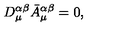

In [131]:
image

**As we can see above, the inference output of the base model dosen't match with the text for this particular image. Hence we need sft**

In [132]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer,SFTConfig 

In [133]:
FastVisionModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2VLForConditionalGeneration(
      (model): Qwen2VLModel(
        (visual): Qwen2VisionTransformerPretrainedModel(
          (patch_embed): PatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-18): 19 x Qwen2VLVisionBlock(
              (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (attn): VisionAttention(
                (qkv): lora.Linear(
                  (base_layer): Linear(in_features=1280, out_features=3840, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1280, out_features=16, bias=Fals

In [137]:
###remove_unused_columns=False this is very important for vision models to keep the information regarding image features intact!!!
args=SFTConfig("Qwen2-VL-7B-Instruct-LoRA-Latex-OCR-Adapter",per_device_train_batch_size=2,gradient_accumulation_steps=4,eval_strategy="no",
               max_steps=100,learning_rate=2e-5,max_seq_length=2048,fp16= not is_bf16_supported(),
               bf16=is_bf16_supported(),weight_decay=0.01,optim="adamw_8bit",remove_unused_columns=False,report_to="wandb")


In [138]:
trainer=SFTTrainer(model=model,args=args,data_collator=UnslothVisionDataCollator(model,tokenizer),train_dataset=dataset,processing_class=tokenizer)

Unsloth: Model does not have a default image size - using 512


In [139]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 68,686 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 50,855,936 of 8,342,231,552 (0.61% trained)


Step,Training Loss
1,0.210926
2,0.122070
3,0.245247
4,0.166895
5,0.116018
6,0.117305
7,0.174044
8,0.134679


KeyboardInterrupt: 

In [ ]:
trainer.push_to_hub()

In [ ]:
FastVisionModel.for_inference(model)

In [ ]:
_=model.generate(**inference_inputs,streamer=text_streamer,max_new_tokens=128,use_cache=True,temperature=1,min_p=0.1)

In [ ]:
raw_dataset[1]['text']

In [ ]:
model,tokenizer=FastVisionModel.from_pretrained("Adnan2942/Qwen2-VL-7B-Instruct-LoRA-Latex-OCR-Adapter",load_in_4bit=True)

In [ ]:
model

In [ ]:
model.push_to_hub_merged("Adnan2942/Qwen2-VL-7B-Instruct-LoRA-Latex-OCR",tokenizer=tokenizer,save_method="merged_16bit")